In [1]:
import numpy as np
import pandas as pd
import os

In [2]:
data = pd.read_csv(r'../data/bpi-challenge-2017/bpi_2017_cleaned.csv')
data.keys()

Index(['Action', 'org:resource', 'concept:name', 'EventOrigin', 'EventID',
       'lifecycle:transition', 'time:timestamp', 'case:LoanGoal',
       'case:ApplicationType', 'case:concept:name', 'case:RequestedAmount',
       'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost',
       'Selected', 'CreditScore', 'OfferedAmount', 'OfferID'],
      dtype='object')

## Cleansing dataset

In [3]:
data

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202262,Deleted,User_1,W_Call after offers,Workflow,Workitem_1817549786,ate_abort,2017-01-06 06:33:02.212000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202263,Created,User_1,W_Call after offers,Workflow,Workitem_363876066,schedule,2017-01-06 06:33:02.221000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202264,statechange,User_28,A_Cancelled,Application,ApplState_1869071797,complete,2017-01-16 09:51:21.114000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202265,statechange,User_28,O_Cancelled,Offer,OfferState_420066181,complete,2017-01-16 09:51:21.139000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1580299144


In [4]:
data = data[data['EventOrigin'] != 'Workflow']

Dropping the useless data

In [5]:
data = data.drop(['Action', 'org:resource','EventOrig'
'in', 'EventID','lifecycle:transition', 'case:LoanGoal','case:ApplicationType', 'case:concept:name'
,'OfferID'], axis= 1)

In [6]:
useful=['A_Cancelled','A_Pending','O_Create Offer','A_Denied']
data=data[data['concept:name'].isin(useful)].reset_index()
data

,index,concept:name,time:timestamp,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount
0,9,O_Create Offer,2016-01-02 11:29:03.994000+00:00,20000.0,20000.0,44.0,True,498.29,True,979.0,20000.0
1,38,A_Pending,2016-01-14 15:49:11.420000+00:00,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,50,O_Create Offer,2016-01-02 11:02:38.994000+00:00,10000.0,500.0,33.0,False,200.00,False,0.0,6000.0
3,68,A_Denied,2016-01-07 13:29:49.671000+00:00,10000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,79,O_Create Offer,2016-01-02 11:05:15.942000+00:00,15000.0,15000.0,120.0,True,158.98,False,0.0,15000.0
...,...,...,...,...,...,...,...,...,...,...,...
74402,1202191,A_Pending,2017-01-23 07:44:22.568000+00:00,10000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74403,1202202,O_Create Offer,2017-01-04 19:30:29.845000+00:00,30000.0,0.0,77.0,True,450.00,True,996.0,30000.0
74404,1202244,A_Pending,2017-01-23 15:13:08.190000+00:00,30000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74405,1202254,O_Create Offer,2017-01-02 19:24:59.501000+00:00,20000.0,20000.0,77.0,False,297.81,False,0.0,20000.0


In [7]:
statlist = []
for i in range(len(data)):
    if data['concept:name'][i] == 'O_Create Offer':
        stats = []
        stats.append(data['case:RequestedAmount'][i])
        stats.append(data['FirstWithdrawalAmount'][i])
        stats.append(data['NumberOfTerms'][i])
        stats.append(data['Accepted'][i])
        stats.append(data['MonthlyCost'][i])
        stats.append(data['Selected'][i])
        stats.append(data['CreditScore'][i])
        stats.append(data['OfferedAmount'][i])
        statlist.append(stats)
    elif data['concept:name'][i] == 'A_Pending':
        stats.append(1)
        statlist.append(stats)
    elif data['concept:name'][i] == 'A_Denied':
        stats.append(-1)
        statlist.append(stats)
    else:
        stats.append(0)
        statlist.append(stats)



In [8]:
statlist=pd.DataFrame(statlist,columns=['RequestedAmount','FirstWithdrawalAmount','NumberOfTerms','Accepted','MonthlyCost','Selected','CreditScore','OfferedAmount','Labels','NULL'])
statlist=statlist.drop(['NULL'],axis=1)

In [9]:
statlist

,RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,Labels
0,20000.0,20000.0,44.0,True,498.29,True,979.0,20000.0,1.0
1,20000.0,20000.0,44.0,True,498.29,True,979.0,20000.0,1.0
2,10000.0,500.0,33.0,False,200.00,False,0.0,6000.0,-1.0
3,10000.0,500.0,33.0,False,200.00,False,0.0,6000.0,-1.0
4,15000.0,15000.0,120.0,True,158.98,False,0.0,15000.0,NaN
...,...,...,...,...,...,...,...,...,...
74402,10000.0,10000.0,120.0,True,106.46,True,854.0,10000.0,1.0
74403,30000.0,0.0,77.0,True,450.00,True,996.0,30000.0,1.0
74404,30000.0,0.0,77.0,True,450.00,True,996.0,30000.0,1.0
74405,20000.0,20000.0,77.0,False,297.81,False,0.0,20000.0,0.0


=== PHÂN BỔ KẾT QUẢ HỒ SƠ ===
Labels
 1.0    54.846155
 0.0    33.207583
-1.0    11.946262
Name: proportion, dtype: float64


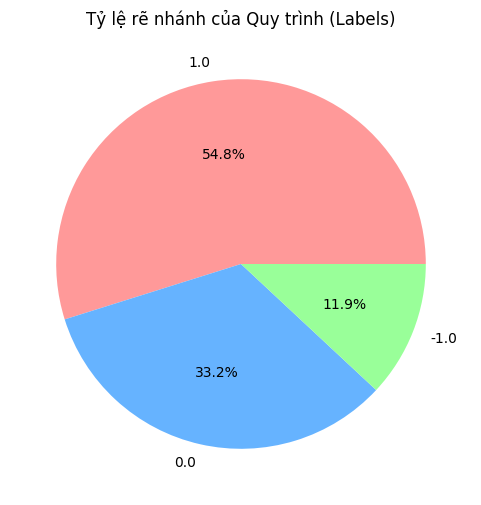

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Kiểm tra số lượng của từng nhãn (1: Pending, 0: Cancelled, -1: Denied)
print("=== PHÂN BỔ KẾT QUẢ HỒ SƠ ===")
print(statlist['Labels'].value_counts(normalize=True) * 100) # Xem tỷ lệ %

# Vẽ biểu đồ tròn
plt.figure(figsize=(6, 6))
statlist['Labels'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Tỷ lệ rẽ nhánh của Quy trình (Labels)')
plt.ylabel('')
plt.show()

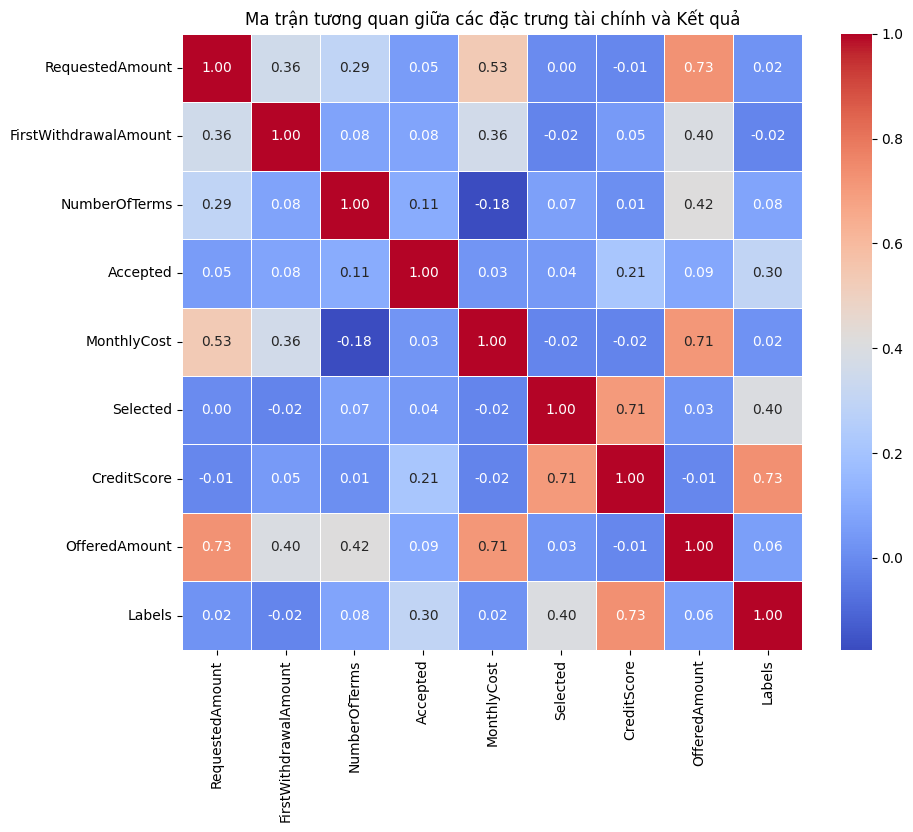

In [11]:
# Tính ma trận tương quan
corr_matrix = statlist.corr()

# Vẽ biểu đồ nhiệt (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng tài chính và Kết quả')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_17260\2538324306.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Labels', y='CreditScore', data=statlist, ax=axes[0], palette='Set2')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17260\2538324306.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Denied (-1)', 'Cancelled (0)', 'Pending (1)'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_17260\2538324306.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Labels', y='RequestedAmount', data=statlist, ax=axes[1], palette='Set3')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17260\2538

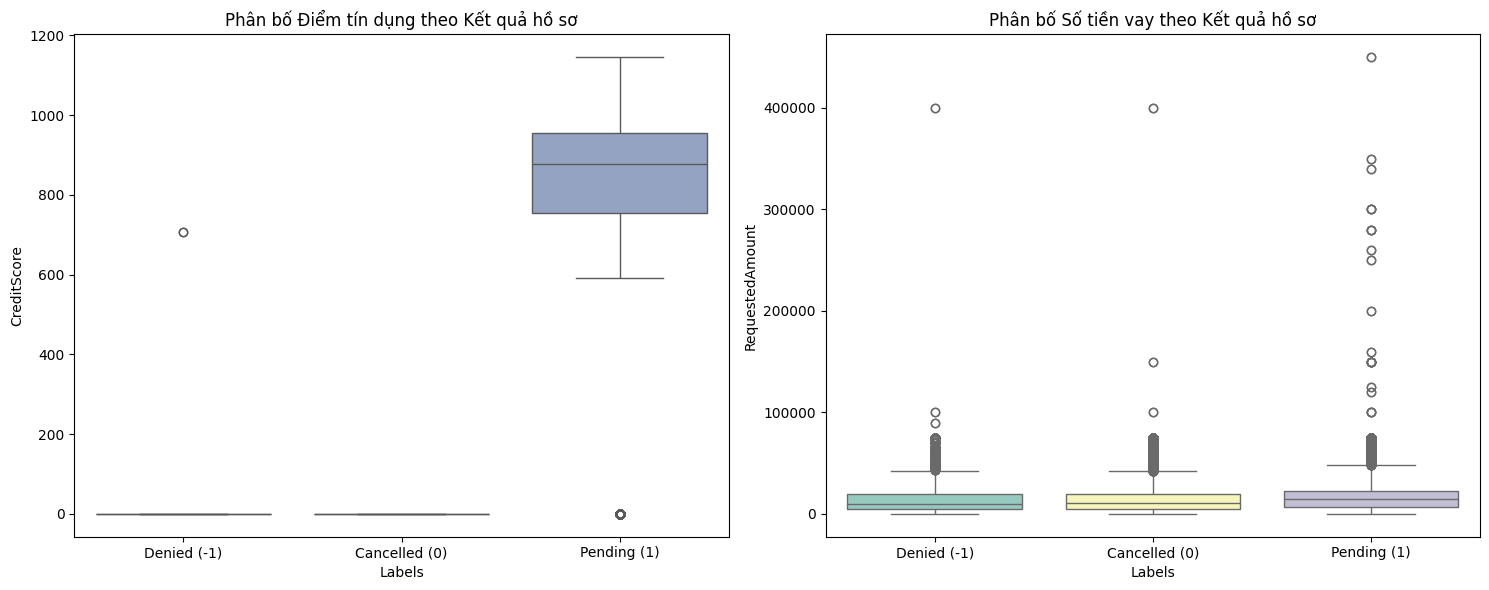

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ 1: Điểm tín dụng vs Kết quả
sns.boxplot(x='Labels', y='CreditScore', data=statlist, ax=axes[0], palette='Set2')
axes[0].set_title('Phân bố Điểm tín dụng theo Kết quả hồ sơ')
axes[0].set_xticklabels(['Denied (-1)', 'Cancelled (0)', 'Pending (1)'])

# Biểu đồ 2: Số tiền vay vs Kết quả
sns.boxplot(x='Labels', y='RequestedAmount', data=statlist, ax=axes[1], palette='Set3')
axes[1].set_title('Phân bố Số tiền vay theo Kết quả hồ sơ')
axes[1].set_xticklabels(['Denied (-1)', 'Cancelled (0)', 'Pending (1)'])

plt.tight_layout()
plt.show()

## Phân tích Chuỗi Thời Gian

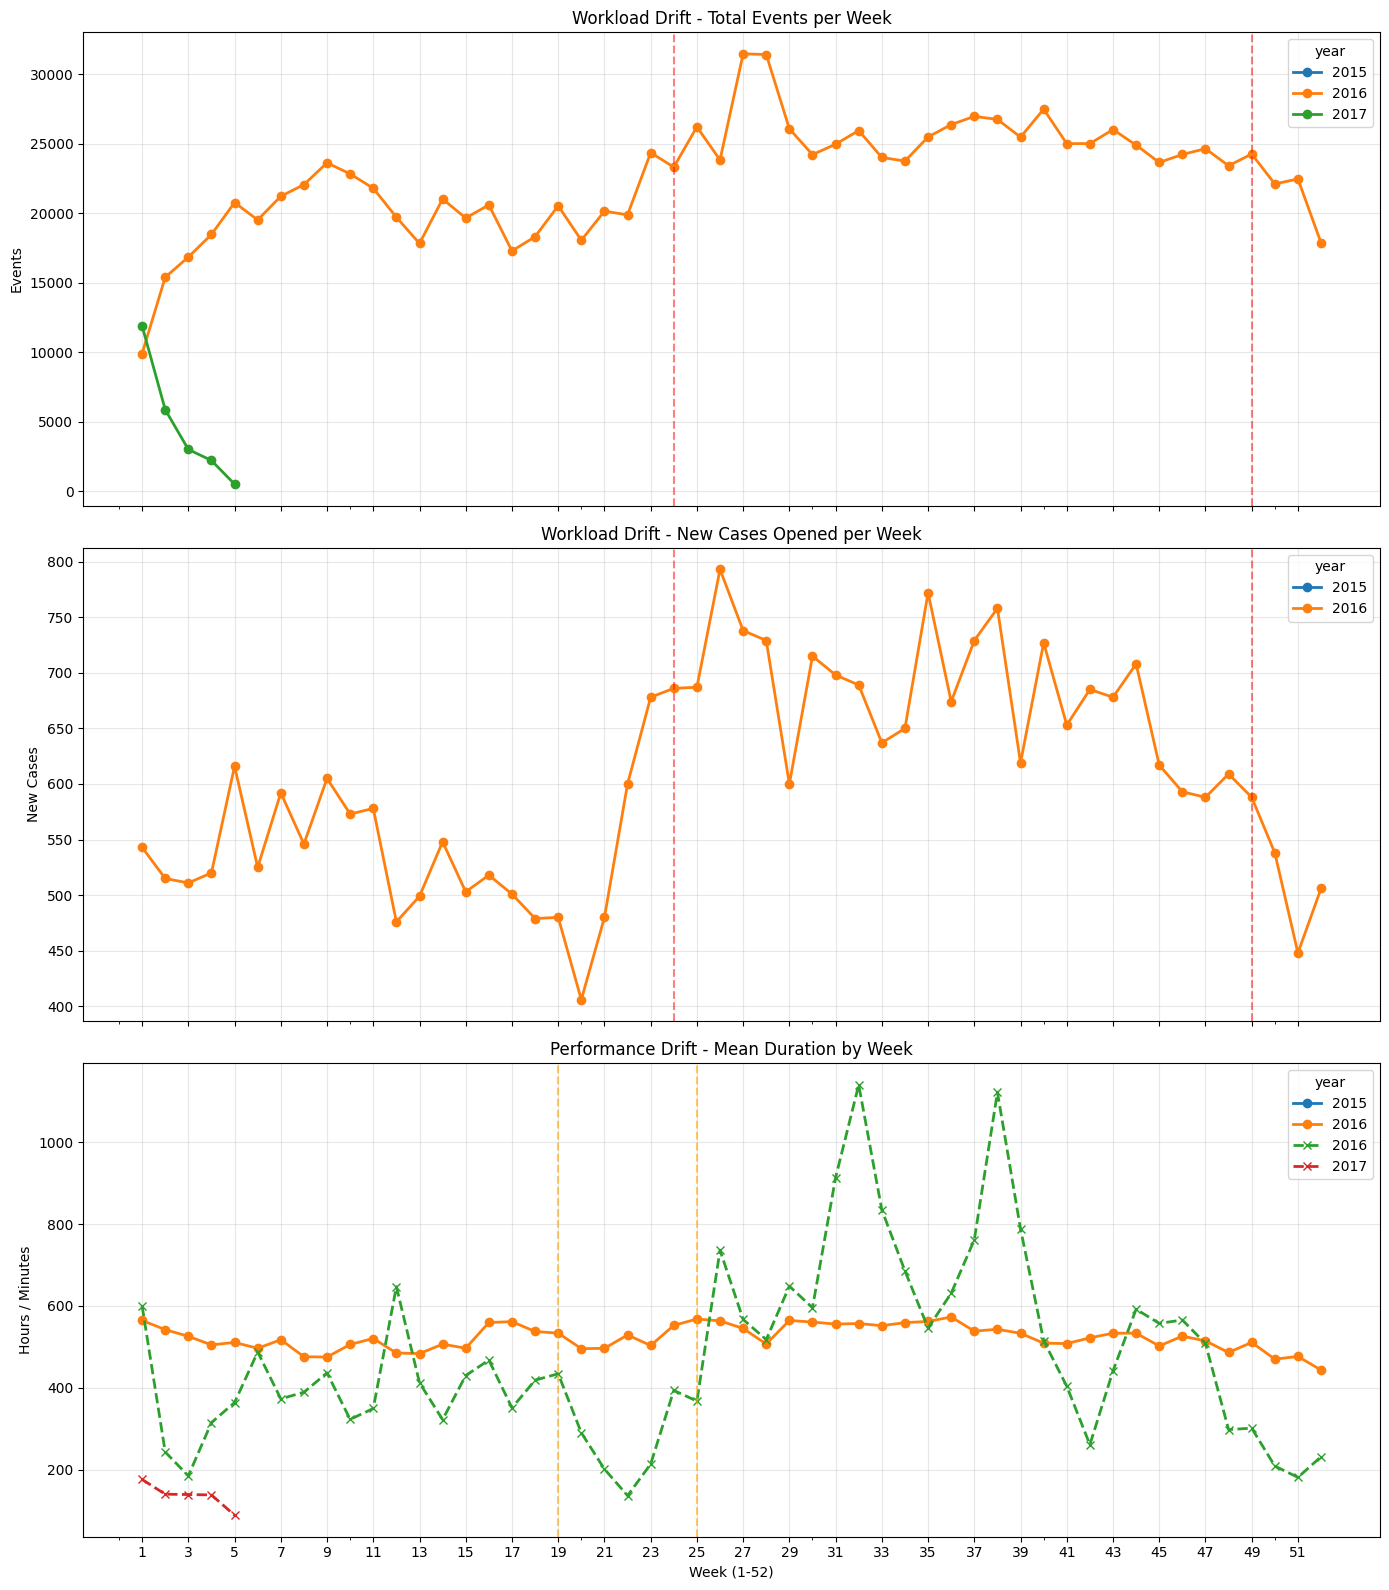

Top tuần có biến động Events:
    year  week  event_count
27  2016    27        31450
28  2016    28        31403
40  2016    40        27473
37  2016    37        26954
38  2016    38        26738
36  2016    36        26366
25  2016    25        26198
29  2016    29        26064
43  2016    43        26008
32  2016    32        25938

Top tuần có Mean Case Duration cao:
    year  week  mean_case_duration_hours
0   2015    53                609.494946
36  2016    36                573.001052
25  2016    25                568.069836
1   2016     1                564.582782
29  2016    29                564.477857
26  2016    26                563.501788
35  2016    35                562.085085
17  2016    17                561.581790
30  2016    30                560.600158
16  2016    16                559.522659

Top tuần có Mean W_Validate duration cao:
    year  week  mean_validate_minutes
31  2016    32            1140.197537
37  2016    38            1122.186280
30  2016    31   

In [15]:
# Weekly drift analysis (Workload + Performance)
import pandas as pd
import matplotlib.pyplot as plt

WEEKS = list(range(1, 53))
WORKLOAD_DRIFT_WEEKS = [24, 49]
PERFORMANCE_DRIFT_WEEKS = [19, 25]


def prepare_data(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Normalize timestamp and extract ISO year/week."""
    data = dataframe.copy()
    data['time:timestamp'] = pd.to_datetime(data['time:timestamp'], errors='coerce')
    data = data.dropna(subset=['time:timestamp']).copy()

    iso = data['time:timestamp'].dt.isocalendar()
    data['year'] = iso.year.astype(int)
    data['week'] = iso.week.astype(int)
    return data


def build_weekly_metrics(data: pd.DataFrame):
    """Compute workload and performance metrics by (year, week)."""
    # Workload: total events per week
    events_weekly = (
        data.groupby(['year', 'week'])
        .size()
        .rename('event_count')
        .reset_index()
    )

    # Workload: new cases opened per week (based on first event timestamp)
    case_start = (
        data.sort_values(['case:concept:name', 'time:timestamp'])
        .groupby('case:concept:name', as_index=False)
        .first()[['case:concept:name', 'time:timestamp']]
    )
    case_start_iso = case_start['time:timestamp'].dt.isocalendar()
    case_start['year'] = case_start_iso.year.astype(int)
    case_start['week'] = case_start_iso.week.astype(int)

    cases_opened_weekly = (
        case_start.groupby(['year', 'week'])
        .size()
        .rename('new_cases')
        .reset_index()
    )

    # Performance: mean case duration by case-start week
    case_span = (
        data.groupby('case:concept:name')['time:timestamp']
        .agg(case_start='min', case_end='max')
        .reset_index()
    )
    case_span['case_duration_hours'] = (
        (case_span['case_end'] - case_span['case_start']).dt.total_seconds() / 3600.0
    )
    case_span_iso = case_span['case_start'].dt.isocalendar()
    case_span['year'] = case_span_iso.year.astype(int)
    case_span['week'] = case_span_iso.week.astype(int)

    mean_case_duration_weekly = (
        case_span.groupby(['year', 'week'])['case_duration_hours']
        .mean()
        .rename('mean_case_duration_hours')
        .reset_index()
    )

    # Performance: mean duration of W_Validate application by week
    step_data = data.sort_values(['case:concept:name', 'time:timestamp']).copy()
    step_data['next_timestamp'] = step_data.groupby('case:concept:name')['time:timestamp'].shift(-1)
    step_data['step_duration_minutes'] = (
        (step_data['next_timestamp'] - step_data['time:timestamp']).dt.total_seconds() / 60.0
    )

    validate_weekly = (
        step_data[
            (step_data['concept:name'] == 'W_Validate application')
            & (step_data['step_duration_minutes'] >= 0)
        ]
        .groupby(['year', 'week'])['step_duration_minutes']
        .mean()
        .rename('mean_validate_minutes')
        .reset_index()
    )

    return events_weekly, cases_opened_weekly, mean_case_duration_weekly, validate_weekly


def to_week_pivot(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    """Pivot to week index 1..52 so the x-axis is stable."""
    return df.pivot(index='week', columns='year', values=value_col).reindex(WEEKS)


def plot_weekly_drift(
    events_weekly: pd.DataFrame,
    cases_opened_weekly: pd.DataFrame,
    mean_case_duration_weekly: pd.DataFrame,
    validate_weekly: pd.DataFrame,
):
    """Plot workload and performance drift over weeks."""
    events_pivot = to_week_pivot(events_weekly, 'event_count')
    cases_pivot = to_week_pivot(cases_opened_weekly, 'new_cases')
    case_duration_pivot = to_week_pivot(mean_case_duration_weekly, 'mean_case_duration_hours')
    validate_pivot = to_week_pivot(validate_weekly, 'mean_validate_minutes')

    fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=True)

    events_pivot.plot(ax=axes[0], marker='o', linewidth=2)
    axes[0].set_title('Workload Drift - Total Events per Week')
    axes[0].set_ylabel('Events')
    axes[0].grid(alpha=0.3)
    for week in WORKLOAD_DRIFT_WEEKS:
        axes[0].axvline(week, color='red', linestyle='--', alpha=0.5)

    cases_pivot.plot(ax=axes[1], marker='o', linewidth=2)
    axes[1].set_title('Workload Drift - New Cases Opened per Week')
    axes[1].set_ylabel('New Cases')
    axes[1].grid(alpha=0.3)
    for week in WORKLOAD_DRIFT_WEEKS:
        axes[1].axvline(week, color='red', linestyle='--', alpha=0.5)

    case_duration_pivot.plot(ax=axes[2], marker='o', linewidth=2)
    validate_pivot.plot(ax=axes[2], marker='x', linewidth=2, linestyle='--')
    axes[2].set_title('Performance Drift - Mean Duration by Week')
    axes[2].set_ylabel('Hours / Minutes')
    axes[2].grid(alpha=0.3)
    for week in PERFORMANCE_DRIFT_WEEKS:
        axes[2].axvline(week, color='orange', linestyle='--', alpha=0.6)

    axes[2].set_xlabel('Week (1-52)')
    axes[2].set_xticks(range(1, 53, 2))
    plt.tight_layout()
    plt.show()


def print_drift_summary(
    events_weekly: pd.DataFrame,
    mean_case_duration_weekly: pd.DataFrame,
    validate_weekly: pd.DataFrame,
):
    """Print top anomalous weeks for quick inspection."""
    print('Top tuần có biến động Events:')
    print(events_weekly.sort_values('event_count', ascending=False).head(10))

    print('\nTop tuần có Mean Case Duration cao:')
    print(mean_case_duration_weekly.sort_values('mean_case_duration_hours', ascending=False).head(10))

    print('\nTop tuần có Mean W_Validate duration cao:')
    print(validate_weekly.sort_values('mean_validate_minutes', ascending=False).head(10))


# Dùng tên biến data đồng bộ với phần đầu notebook
data = pd.read_csv(r'../data/bpi-challenge-2017/bpi_2017_cleaned.csv')
data = prepare_data(data)

(
    events_weekly,
    cases_opened_weekly,
    mean_case_duration_weekly,
    validate_weekly,
) = build_weekly_metrics(data)

plot_weekly_drift(
    events_weekly,
    cases_opened_weekly,
    mean_case_duration_weekly,
    validate_weekly,
)

print_drift_summary(
    events_weekly,
    mean_case_duration_weekly,
    validate_weekly,
)

### Mean case duration là thời gian hoàn thành hồ sơ trung bình 
## Nhận xét:
- Nhìn vào biểu đồ "New Cases Opened", trước tuần 24, số lượng hồ sơ dao động đều đặn quanh mốc 500-600. Tại đúng tuần 24, đồ thị bắt đầu bẻ lái và tăng vọt thẳng đứng lên mức gần 800 ở tuần 26
- Tuần 49: Đây là điểm đồ thị đang ở mức cao (khoảng 600 cases) thì đột ngột cắm đầu rơi thẳng đứng rớt xuống dưới mốc 450.
- Đối với Tuần 19 và 25 (Performance Drift - Đường gạch đứt màu vàng ở biểu đồ 3): đường màu xanh (W_validate application) sau tuần 15 giao động rất mạnh và ở trong đoạn từ tuần 19 - 25 có một đoạn giảm sâu thể hiện được có sự thay đổi quy trình hoặc vấn đề trong quy trình dẫn đến những vấn đề trên